In [29]:
import warnings
warnings.filterwarnings('ignore')
                        
from hbb import utils
import argparse
import gc
import pickle
from pathlib import Path
import hist
import numpy as np
import uproot
import json
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import csv
import os

hep.style.use("CMS")

from common_bb_cc import common_mc, data_by_year, higgs_mc#data_by_year_muon, data_by_year_zgamma

In [30]:
N_batches = 10

data_name = "4Cat_26Aug13"

MAIN_DIR = "/eos/uscms/store/group/lpchbbrun3/"
dir_name = "skims/26Jun12/"
# dir_name = "skims/26May18/"
# dir_name = "gmachado/24Aug07_v15/"

# save_dir = "/uscms/home/bweiss/nobackup/hbb-run3/data/BDT_data"

save_dir = "/uscms/home/bweiss/nobackup/hbb-run3/data/4cat_BDT_data_22_nocc"

# years = ['2022', '2022EE', '2023','2023BPix', '2024'
#         ]
year2era = {#'2023BPix':2023.5, 
            '2022':2022, 
            # '2022EE':2022.5, 
            # '2023':2023, 
            # '2024':2024
           }
# years = ['2024']

samples = {**common_mc}

proc2cat = {'tt': "ttbar",
              "vbf-hbb": "vbf", 
              # "vbf-hcc": "vbf", 
              "vh-hbb": "vh", 
              # # "vh-hcc": "vh", 
              'ggf-hbb': "ggf", 
              # 'ggf-hcc': "ggf",
              
            }
cat2label = {"ttbar":3,
             "vbf": 0,
             "vh": 1 ,
             "ggf": 2 ,
            }
with open('../data/MultiBDT_3cat_26Jun2_features.csv', mode='r', newline='', encoding='utf-8') as file:
    bdt_features = []
    csv_reader = csv.reader(file)
    for row in csv_reader:
        bdt_features += row

load_columns = bdt_features
load_columns +=["weight"]
load_columns +=[#'FatJet0_ParTPTopbWq', 'FatJet0_ParTPTopbWqq',
    'FatJet1_ParTPTopbWq', 'FatJet1_ParTPTopbWqq', 'nJet_outsideFatJet0', 'nJet_opphemFatJet0',
    'FatJet0_pt', 'FatJet0_msd',]

print(load_columns)
metadata = None
# load_columns = ["weight", "FatJet0_msd", "FatJet0_ParTPXbbXcc", "FatJet0_ParTPXccVsQCD", "FatJet0_ParTPXbbVsQCD", "BDT_score"]

['nFatJet', 'nJet', 'FatJet0_phi', 'FatJet0_eta', 'FatJet0_n2b1', 'FatJet0_n3b1', 'FatJet1_pt', 'FatJet1_phi', 'FatJet1_eta', 'FatJet1_msd', 'VBFPair_mjj', 'VBFPair_deta', 'FatJet1_ParTPQCD', 'FatJet1_ParTPXbb', 'FatJet1_ParTPXcc', 'FatJet1_ParTPXqq', 'FatJet1_ParTPXcs', 'FatJet1_ParTPXbbVsQCD', 'FatJet1_ParTPXccVsQCD', 'FatJet1_ParTPXbbXcc', 'FatJet1_ParTmassX2p', 'Jet0_pt', 'Jet0_eta', 'Jet0_phi', 'Jet0_mass', 'Jet0_btagPNetB', 'Jet0_btagPNetCvB', 'Jet0_btagPNetCvL', 'Jet0_btagPNetQvG', 'Jet1_pt', 'Jet1_eta', 'Jet1_phi', 'Jet1_mass', 'Jet1_btagPNetB', 'Jet1_btagPNetCvB', 'Jet1_btagPNetCvL', 'Jet1_btagPNetQvG', 'Jet2_pt', 'Jet2_eta', 'Jet2_phi', 'Jet2_mass', 'Jet2_btagPNetB', 'Jet2_btagPNetCvB', 'Jet2_btagPNetCvL', 'Jet2_btagPNetQvG', 'Jet3_pt', 'Jet3_eta', 'Jet3_phi', 'Jet3_mass', 'Jet3_btagPNetB', 'Jet4_btagPNetCvB', 'Jet4_btagPNetCvL', 'Jet4_btagPNetQvG', 'JetClosestFatJet0_pt', 'JetClosestFatJet0_eta', 'JetClosestFatJet0_phi', 'JetClosestFatJet0_mass', 'weight', 'FatJet1_ParTPTopb

In [31]:
''' WARNING: DELETES EXISTING DATA!! Creates a fresh set of batch parquets '''
os.makedirs(save_dir, exist_ok=True)
for i in range(N_batches): #N_batches
    path = save_dir+f'/batch_{i}.parquet'
    if os.path.exists(path):
        os.remove(path)
    df = pd.DataFrame()
    df.to_parquet(save_dir+f'/batch_{i}.parquet')

In [13]:
'''Cut definitions'''
def minjetkin(df):
    # print(df)
    # fatjets = df['ak8FatJetmsoftdrop', 'ak8FatJetPt', 'ak8FatJetEta']
    # print(df['ak8FatJetmsoftdrop'].shape)
    fatjet_msd = df['FatJet0_msd']
    fatjet_pt = df['FatJet0_pt']
    fatjet_eta = df['FatJet0_eta']
        # fatjets['msdcorr'] = fatjets.msoftdrop
        # fatjets['qcdrho'] = 2 * np.log(fatjets.msdcorr / fatjets.pt)
    candidatejet = df[
            (fatjet_pt > 200)
            & (abs(fatjet_eta) < 2.5)
            # & fatjets.isTight 
        ]

    # candidatejet = candidatejet[:, :2]
    # candidatejet = ak.firsts(candidatejet[ak.argmax(candidatejet.particleNet_XbbVsQCD, axis=1, keepdims=True)])

    # bvl = candidatejet.particleNet_XbbVsQCD
    minjetkin=np.array([
            (candidatejet['FatJet0_pt'] >= 450)
            & (candidatejet['FatJet0_pt']< 1200)
            & (candidatejet['FatJet0_msd'] >= 40.)
            & (candidatejet['FatJet0_msd'] < 201.)
            & (abs(candidatejet['FatJet0_eta']) < 2.5)
       ])
    # minjetkin=np.sum(minjetkin, axis=1).astype('bool').transpose()
    minjetkin = minjetkin.astype('bool').transpose()

    # print(minjetkin)
    # print(minjetkin.shape)
    # print(minjetkin)
    
    return df[minjetkin]

In [32]:
'''Create training metadata'''
metadata = {}
metadata['datasets'] = {year:[] for year in year2era.keys()}
metadata['years'] = list(year2era.keys())
metadata['year2era'] = year2era
metadata['weight_by_year'] = {year:0 for year in year2era.keys()}
metadata['weight_by_cat'] = {cat:0 for cat in cat2label.keys()}

# MC_names = []
# for process, datasets in samples.items():
#     these_names = [n for n in datasets]
#     MC_names+=these_names
# metadata['weight_by_MC'] = {name:0 for name in MC_names}

for year, era in year2era.items():
    path_to_dir = f"{MAIN_DIR}/{dir_name}/"
    data_dir = Path(path_to_dir) / year
    for process, datasets in samples.items():
        if process in proc2cat.keys():
            
            # print(process)        
            for dataset in datasets:
                metadata['datasets'][year].append(dataset)
                data = utils.load_samples(
                    data_dir,
                    {process: [dataset]},
                    columns=['weight', 'FatJet0_pt', 'FatJet0_msd', 'FatJet0_eta'
                            ],
                    region='signal-all',
                    filters=None,
                )
                # print(data[process].columns)
                # print(dict(data.items())[process])
                if data:
                    events = pd.DataFrame(data.get(process))
                    # events = minjetkin(events)
                    
                    #CHANGED
                    # print(len(events))
                    # ptcut = events[process]['FatJet1_pt'] >= 450
                    # events[process] = events[process][ptcut]
                    # print(len(events))
                    
                    metadata['weight_by_year'][year] += np.sum(events['finalWeight'])
                    metadata['weight_by_cat'][proc2cat[process]] += np.sum(events['finalWeight'])
                    # metadata['weight_by_MC'][dataset] += np.sum(events[process]['finalWeight'])
                    # metadata['sumw'] = get_sum_genweights(Path('/uscms/home/bweiss/nobackup/hbb/26May18_2022EE'), data_dir+'/'+dataset)

# metadata['weight_by_cat']['ttbar'] = metadata['weight_by_cat']['ttbar']*10
with open(save_dir+"/metadata.pkl", "wb") as file:
    pickle.dump(metadata, file)


[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/GluGluHto2B_PT-200_M-125/parquet/nominal/signal-all

Using sum_genweights for GluGluHto2B_PT-200_M-125: 2311145.5
Loaded GluGluHto2B_PT-200_M-125                          : 419857 entries

[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/GluGluHto2B_M-125/parquet/nominal/signal-all

[DEBUG] Path does not exist: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/GluGluHto2B_M-125/parquet/nominal/signal-all

[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/WplusH_Hto2B_Wto2Q_M-125/parquet/nominal/signal-all

Using sum_genweights for WplusH_Hto2B_Wto2Q_M-125: 3433325.0
Loaded WplusH_Hto2B_Wto2Q_M-125                          : 39480 entries

[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/ggZH_Hto2B_Zto2Q_M-125/parquet/nominal/signal-all

Using sum_genweights for ggZH_Hto2B_Z

In [33]:
if not metadata:
    print('loading metadata from ', save_dir+"/metadata.pkl")
    with open(save_dir+"/metadata.pkl", "rb") as file:
        metadata = pickle.load(file)
print(metadata)

{'datasets': {'2022': ['GluGluHto2B_PT-200_M-125', 'GluGluHto2B_M-125', 'WplusH_Hto2B_Wto2Q_M-125', 'ggZH_Hto2B_Zto2Q_M-125', 'ZH_Hto2B_Zto2Q_M-125', 'WminusH_Hto2B_Wto2Q_M-125', 'VBFHto2B_M-125', 'VBFHto2B_M-125_dipoleRecoilOn', 'TTtoLNu2Q', 'TTto2L2Nu', 'TTto4Q']}, 'years': ['2022'], 'year2era': {'2022': 2022}, 'weight_by_year': {'2022': np.float64(85397.9093023483)}, 'weight_by_cat': {'ttbar': np.float64(84627.36561813613), 'vbf': np.float64(115.92952721719477), 'vh': np.float64(81.05295353919996), 'ggf': np.float64(573.5612034557671)}}


In [34]:
for year, era in year2era.items():
    path_to_dir = f"{MAIN_DIR}/{dir_name}/"
    data_dir = Path(path_to_dir) / year
    for process, datasets in samples.items():
        if process in proc2cat.keys():
            
            # print(process)        
            for dataset in datasets:
                # metadata['datasets'].append([dataset])
                data = utils.load_samples(
                    data_dir,
                    {process: [dataset]},
                    columns=load_columns,
                    region='signal-all',
                    filters=None,
                )
                # print(data[process].columns)
                # print(dict(data.items())[process])
                if data:
                    events = data.get(process)
                    # events = minjetkin(events)
                    
                    ### Append additional variables ###
                    events['category'] = proc2cat[process]
                    events['y'] = cat2label[proc2cat[process]]
                    # events[process]['MC_name'] = dataset
                    # print(process, proc2cat[process], cat2label[proc2cat[process]])
                    # events[process]["year"] = era
                    events["era"] = era
                    events["BDT_weight"] = 1E6 * abs(events["finalWeight"]) / (metadata['weight_by_year'][year] * metadata['weight_by_cat'][proc2cat[process]])
                    events["BDT_era_weight"] = 1E3 * abs(events["finalWeight"]) / metadata['weight_by_year'][year]
                    events["BDT_cat_weight"] = 1E3 * abs(events["finalWeight"]) / metadata['weight_by_cat'][proc2cat[process]]
                    # events[process]["BDT_MC_weight"] = 1E3 * abs(events[process]["finalWeight"]) / metadata['weight_by_MC'][dataset]
                    print(year, process, len(events))
                    N_events = len(events)
                    per_batch = N_events//N_batches
                    if 'VBFPair_deta' in load_columns:
                        bad_mask = events['VBFPair_deta'] == -1
                        # print('VBFPair_deta=-1 corrected: ', np.sum(bad_mask))
                        events['VBFPair_deta'][bad_mask] = np.nan
                    for i in range(N_batches): #N_batches
                        slice_i = i*per_batch
                        slice_f = (i+1)*per_batch
                        # print(slice_i, slice_f)
                        df = pd.read_parquet(save_dir+f'/batch_{i}.parquet')
                        df = pd.concat([df, events.iloc[slice_i:slice_f]], ignore_index=True)
                        df.to_parquet(save_dir+f'/batch_{i}.parquet')


[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/GluGluHto2B_PT-200_M-125/parquet/nominal/signal-all

Using sum_genweights for GluGluHto2B_PT-200_M-125: 2311145.5
Loaded GluGluHto2B_PT-200_M-125                          : 419857 entries
2022 ggf-hbb 419857

[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/GluGluHto2B_M-125/parquet/nominal/signal-all

[DEBUG] Path does not exist: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/GluGluHto2B_M-125/parquet/nominal/signal-all

[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/WplusH_Hto2B_Wto2Q_M-125/parquet/nominal/signal-all

Using sum_genweights for WplusH_Hto2B_Wto2Q_M-125: 3433325.0
Loaded WplusH_Hto2B_Wto2Q_M-125                          : 39480 entries
2022 vh-hbb 39480

[DEBUG] Script is searching in path: /eos/uscms/store/group/lpchbbrun3/skims/26Jun12/2022/ggZH_Hto2B_Zto2Q_M-125/parquet/nominal/signal-all


In [38]:
save_dir = "/uscms/home/bweiss/nobackup/hbb-run3/data/4cat_BDT_data_22_nocc"

df_test = pd.read_parquet(save_dir+"/batch_2.parquet")
print(df_test.columns)
print(df_test.sample(frac=1, ignore_index=True).tail())
print(df_test['VBFPair_deta'])

for cat, lab in cat2label.items():
    catmask = df_test['y']== lab
    print(cat, np.sum(df_test['BDT_cat_weight'][catmask]))

for year, era in year2era.items():
    yearmask = df_test['era']== era
    print(year, np.sum(df_test['BDT_cat_weight'][yearmask]))

for cat, lab in cat2label.items():
    catmask = df_test['y']== lab
    for year, era in year2era.items():
        yearmask = df_test['era']== era
        print(cat, year, np.sum(df_test['BDT_cat_weight'][yearmask&catmask]))

Index(['nFatJet', 'nJet', 'FatJet0_phi', 'FatJet0_eta', 'FatJet0_n2b1',
       'FatJet0_n3b1', 'FatJet1_pt', 'FatJet1_phi', 'FatJet1_eta',
       'FatJet1_msd', 'VBFPair_mjj', 'VBFPair_deta', 'FatJet1_ParTPQCD',
       'FatJet1_ParTPXbb', 'FatJet1_ParTPXcc', 'FatJet1_ParTPXqq',
       'FatJet1_ParTPXcs', 'FatJet1_ParTPXbbVsQCD', 'FatJet1_ParTPXccVsQCD',
       'FatJet1_ParTPXbbXcc', 'FatJet1_ParTmassX2p', 'Jet0_pt', 'Jet0_eta',
       'Jet0_phi', 'Jet0_mass', 'Jet0_btagPNetB', 'Jet0_btagPNetCvB',
       'Jet0_btagPNetCvL', 'Jet0_btagPNetQvG', 'Jet1_pt', 'Jet1_eta',
       'Jet1_phi', 'Jet1_mass', 'Jet1_btagPNetB', 'Jet1_btagPNetCvB',
       'Jet1_btagPNetCvL', 'Jet1_btagPNetQvG', 'Jet2_pt', 'Jet2_eta',
       'Jet2_phi', 'Jet2_mass', 'Jet2_btagPNetB', 'Jet2_btagPNetCvB',
       'Jet2_btagPNetCvL', 'Jet2_btagPNetQvG', 'Jet3_pt', 'Jet3_eta',
       'Jet3_phi', 'Jet3_mass', 'Jet3_btagPNetB', 'Jet4_btagPNetCvB',
       'Jet4_btagPNetCvL', 'Jet4_btagPNetQvG', 'JetClosestFatJet0_pt',
       

ttbar
vbf
vh
ggf


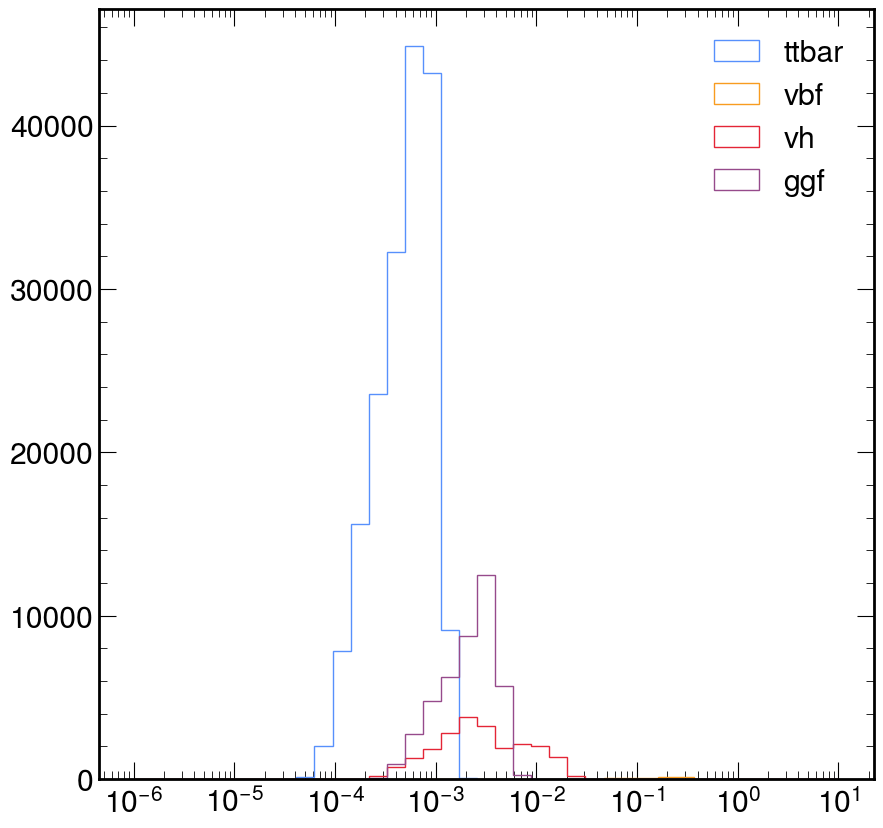

In [39]:
bins = np.logspace(-6, 1, num=40)

for cat, lab in cat2label.items():
    print(cat)
    catmask = df_test['y']== lab
    plt.hist(df_test['BDT_cat_weight'][catmask], bins = bins, histtype='step', label = cat)
plt.xscale('log')
plt.legend()